# CNN Multi Dim Analysis

## 20251128_172209

### Imports

In [9]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import json
import pandas as pd

sys.path.insert(0, os.path.join(os.path.abspath(os.pardir), "src"))
from molearn.data import PDBData
from molearn.models.CNN_autoencoder import AutoEncoder
from molearn.analysis import MolearnAnalysis
from molearn.analysis.plot import *

import torch

### Loading Datasets

In [10]:
atoms = ["N", "CA", "C", "O", 'CB']

mean = json.load(open("data_statistics.json"))["mean"]
std = json.load(open("data_statistics.json"))["std"]

data_closed = PDBData(
    filename=["../data/MurD_closed.pdb"],
    atoms=atoms,
    fix_terminal=True,
)
_ = data_closed.prepare_dataset(mean=mean, std=std)

data_open = PDBData(
    filename=["../data/MurD_open.pdb"],
    atoms=atoms,
    fix_terminal=True,
)
_ = data_open.prepare_dataset(mean=mean, std=std)

data_test = PDBData(
    filename=["../data/MurD_closed_apo.pdb"],
    atoms=atoms,
    fix_terminal=True,
)
_ = data_test.prepare_dataset(mean=mean, std=std)

Using pre-computed mean: 44.62627486293633, std: 13.831951414466797
Dataset shape: torch.Size([900, 2145, 3])
Using pre-computed mean: 44.62627486293633, std: 13.831951414466797
Dataset shape: torch.Size([900, 2145, 3])
Using pre-computed mean: 44.62627486293633, std: 13.831951414466797
Dataset shape: torch.Size([900, 2145, 3])


### Loading the results

In [ ]:
log_dfs = {}
min_valid_losses = {}
min_valid_mse_losses = {}
models = {}

base_path = r"../results/20251128_172209/cnn_multi_dim"

device = 'cuda' if torch.cuda.is_available() else 'cpu'

for n in range(2, 11):

    log_dfs[n] = pd.read_csv(Path(f"{base_path}/{n}/log.dat"))
    best_epoch = log_dfs[n]['valid_loss'].idxmin()
    min_valid_losses[n] = min(log_dfs[n].valid_loss)
    min_valid_mse_losses[n] = min(log_dfs[n].valid_mse_loss)

    checkpoint_path = Path(f"{base_path}/{n}/checkpoint_converged.ckpt")
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

    model = AutoEncoder(latent_z=n)
    model.load_state_dict(checkpoint['model_state_dict'])

    models[n] = model

MA = MolearnAnalysis()
MA.batch_size = 16
MA.processes = 4

MA.set_dataset(data=data_open, key="train_open")
MA.set_dataset(data=data_closed, key="train_closed")
MA.set_dataset(data=data_test, key="test_trans")

MA.set_network(model[2])

### MSE Plots 

In [ ]:
# Plot line graph of minimum validation losses
plt.figure(figsize=(10, 6))
plt.plot(list(min_valid_losses.keys()), list(min_valid_losses.values()), marker='o', linewidth=2, markersize=8)
plt.xlabel('Latent Dimension', fontsize=12)
plt.ylabel('Minimum Validation Loss', fontsize=12)
plt.title('Minimum Validation Loss by Latent Dimension', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot line graph of minimum validation MSE_losses
plt.figure(figsize=(10, 6))
plt.plot(list(min_valid_mse_losses.keys()), list(min_valid_mse_losses.values()), marker='o', linewidth=2, markersize=8)
plt.xlabel('Latent Dimension', fontsize=12)
plt.ylabel('Minimum Validation MSE Loss', fontsize=12)
plt.title('Minimum Validation MSE Loss by Latent Dimension', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



### Model plots

#### RMSD Hist plot

encoding train_open: 57it [00:00, 111.23it/s]
Decoding train_open: 57it [00:00, 115.64it/s]
encoding train_closed: 57it [00:00, 87.98it/s] 
Decoding train_closed: 57it [00:00, 113.00it/s]
encoding test_trans: 57it [00:00, 107.11it/s]
Decoding test_trans: 57it [00:00, 110.90it/s]


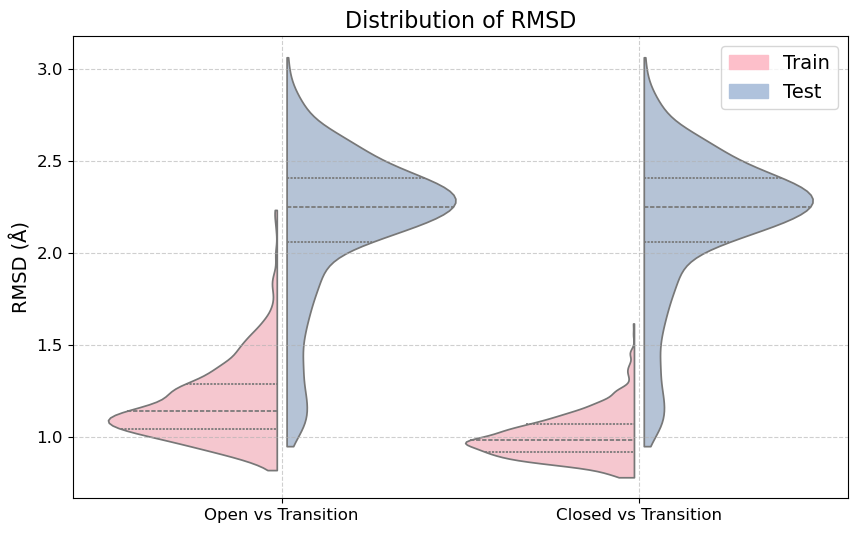

In [25]:
rmsd_train_open = MA.get_error('train_open')
rmsd_train_closed = MA.get_error('train_closed')
rmsd_test_trans = MA.get_error('test_trans')

rmsd_plot_data = [
    ("train_open", "test_trans", "Open vs Transition", "train", "test"),
    ("train_closed", "test_trans", "Closed vs Transition", "train", "test"),
]

plot_rmsd_hist(
    MA,
    plot_data=rmsd_plot_data,
    dpi=150,
)

#### Bondlength Hist plots

encoding train_open: 57it [00:00, 77.83it/s] 
Decoding train_open: 57it [00:00, 111.97it/s]
encoding train_closed: 57it [00:00, 78.93it/s]
Decoding train_closed: 57it [00:00, 97.98it/s]
encoding test_trans: 57it [00:00, 123.30it/s]
Decoding test_trans: 57it [00:00, 109.55it/s]


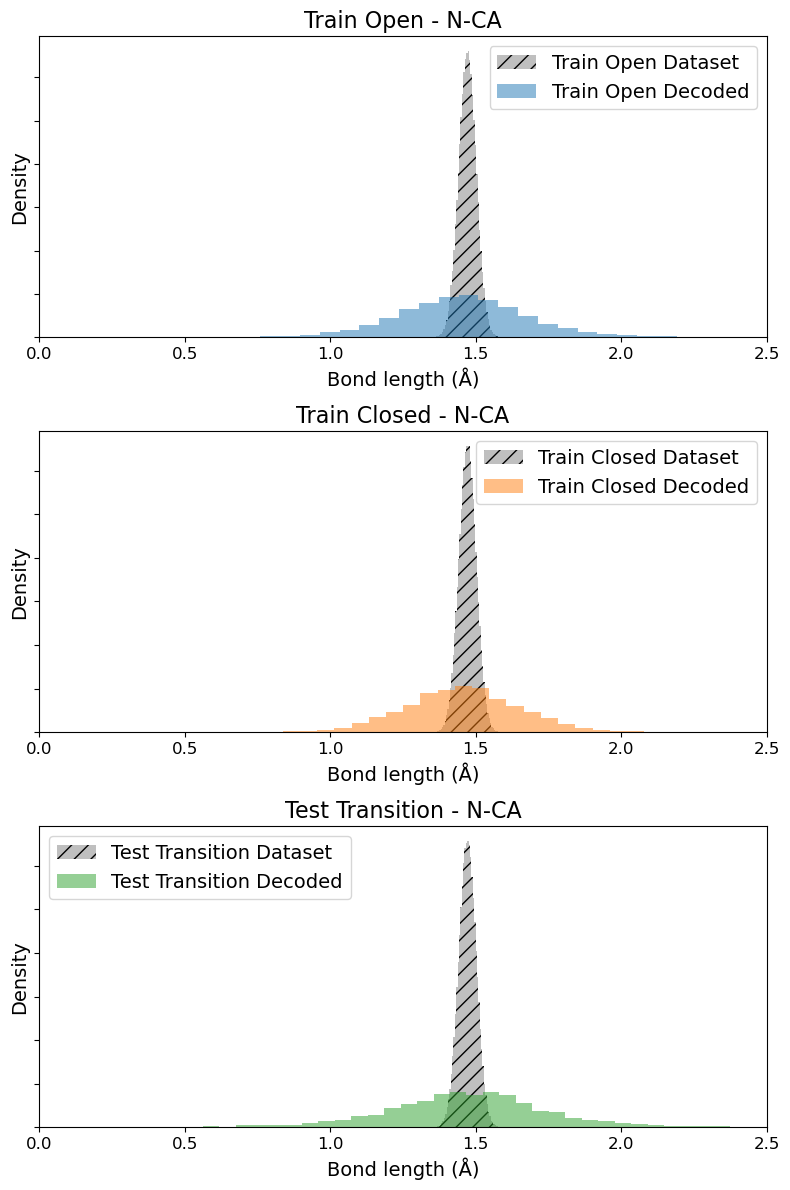

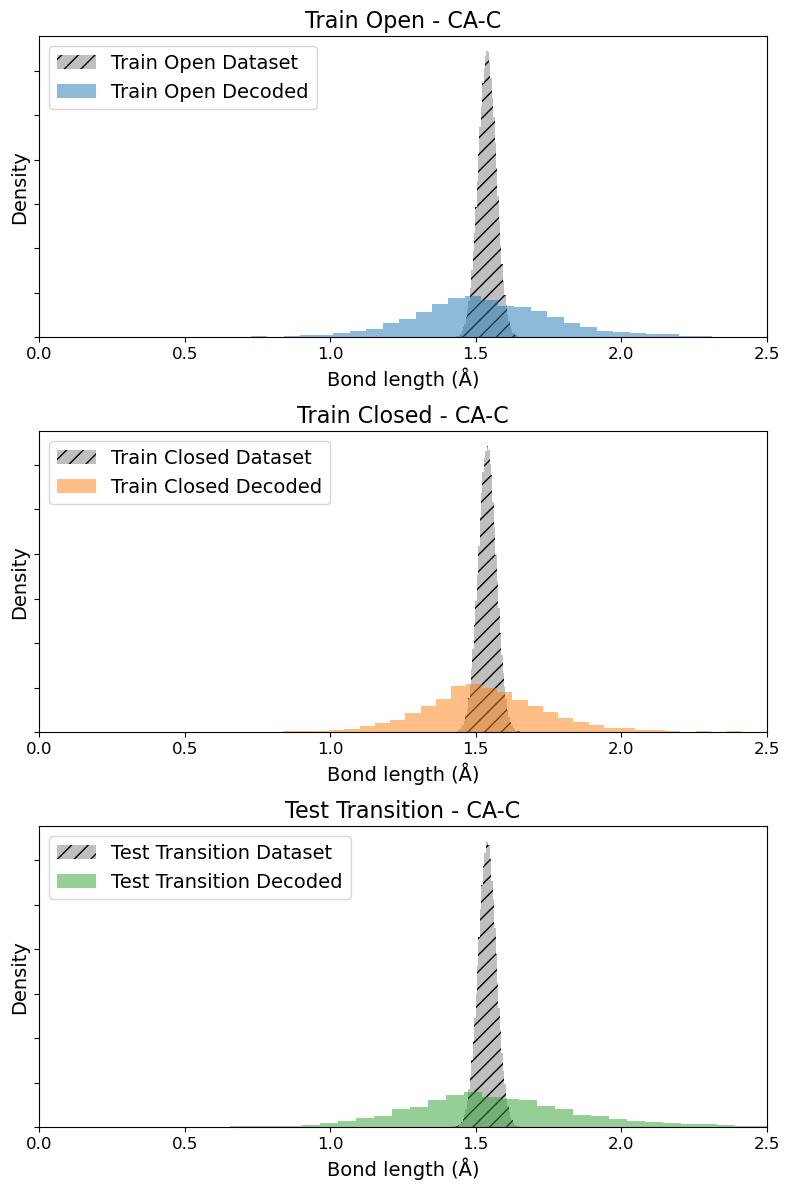

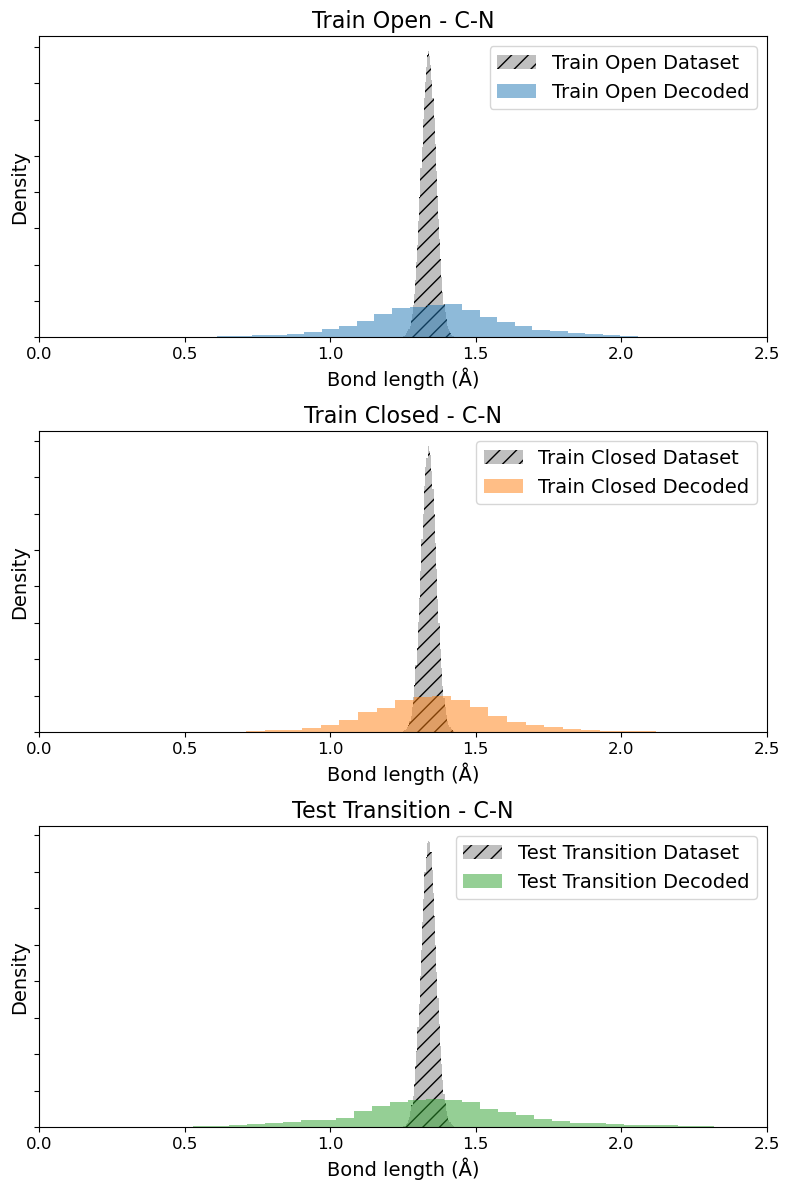

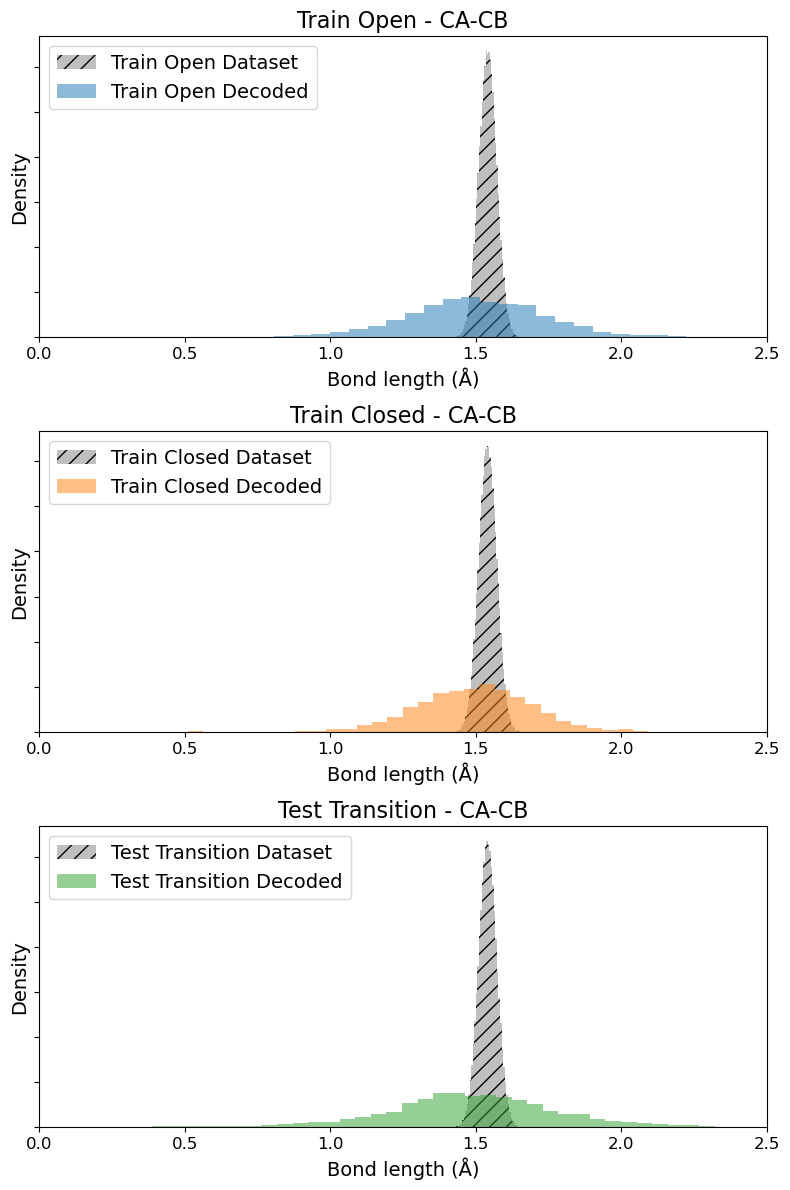

In [6]:
bondlength_train_open = MA.get_bondlengths('train_open')
bondlength_train_closed = MA.get_bondlengths('train_closed')
bondlength_test_trans = MA.get_bondlengths('test_trans')

bondlength_plot_data = [
    ("train_open", "Train Open", "#1f77b4"),
    ("train_closed", "Train Closed", "#ff7f0e"),
    ("test_trans", "Test Transition", "#2ca02c"),
]

plot_bondlength_hist(
    MA,
    plot_data=bondlength_plot_data,
    bins=60,
    dpi=150,
)

#### Inversion Hist Plot

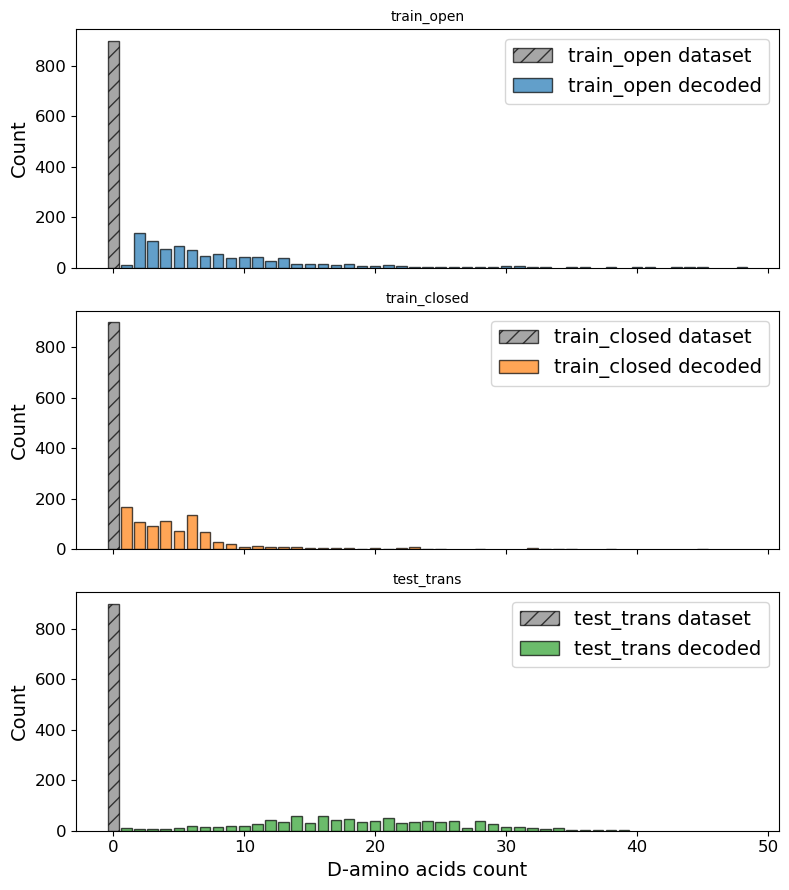

In [27]:
inversion_plot_data = [('train_open', 'train_open', "#1f77b4"),
                       ('train_closed', 'train_closed',"#ff7f0e"),
                       ('test_trans', 'test_trans', "#2ca02c")]

plot_inversion_hist(MA, 
                    plot_data = inversion_plot_data,
                    )

#### Dope score across the latent space

encoding train_open: 57it [00:01, 36.89it/s]
encoding train_closed: 57it [00:00, 97.23it/s]
encoding test_trans: 57it [00:00, 92.86it/s] 


Latent grid 'grid' initialised with 20 samples per axis.


Decoding grid: 25it [00:00, 71.13it/s]
Calc Dope: 100%|██████████| 400/400 [00:25<00:00, 15.54it/s]


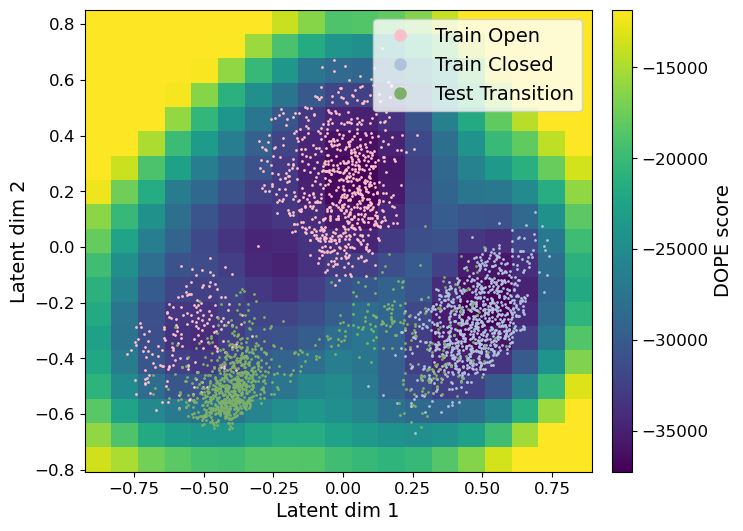

In [12]:
# We first setup a latent grid whose boundaries encompass all datasets.
if "grid" not in MA._encoded:
    grid_key = MA.setup_grid(samples=20)
    print(f"Latent grid '{grid_key}' initialised with {MA.n_samples} samples per axis.")
else:
    grid_key = "grid"
    print("Re-using previously initialised latent grid.")

# Next, we compute the DOPE surface over the latent grid.
dope_surface, xvals, yvals = MA.scan_dope(refine=True)
surface_clip = np.percentile(dope_surface, 80)

dope_plot_data = [
    ("train_open", "Train Open", "#FDBFCA", "scatter"),
    ("train_closed", "Train Closed", "#AFC2DC", "scatter"),
    ("test_trans", "Test Transition", "#7FB069", "scatter"),
]

plot_dope_surface(
    MA,
    refine=True,
    truncate_at=surface_clip,
    plot_data=dope_plot_data,
    cmap="viridis",
    bbox_inches="tight",
)

### PCA

In [ ]:
### Create a PCA decomposition of the latent 2D space, returning the variance account for by the top 2 eigen vectors

model = models[10]

